<a href="https://colab.research.google.com/github/dee431/Properties-of-Protein-Tertiary-Structure/blob/main/Properties_of_Protein_Tertiary_Structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
samanemami_properties_of_protein_tertiary_structure_path = kagglehub.dataset_download('samanemami/properties-of-protein-tertiary-structure')

print('Data source import complete.')


100%|██████████| 1.60M/1.60M [00:00<00:00, 120MB/s]

Extracting files...
Data source import complete.


# Protein Structure Quality Clustering
### Physicochemical Properties of Protein Tertiary Structure (CASP 5–9)

---

## Overview

This notebook explores how the **physicochemical properties** of protein structure decoys relate to their **prediction quality**, as measured by RMSD (Root Mean Square Deviation) from the experimentally determined native structure.

**Key questions:**
- Can we meaningfully separate high-quality, medium-quality, and poor-quality decoys using their physicochemical features?
- Which features best distinguish a well-predicted structure from a poorly predicted one?
- What does unsupervised K-Means clustering reveal about the natural groupings in this data?

**Dataset:** 45,730 decoys from CASP 5–9, each described by 9 physicochemical features (F1–F9) and an RMSD value (0–21 Å).

## Feature Dictionary

| Feature | Physical Meaning | Unit |
|---------|-----------------|------|
| **RMSD** | Deviation from native structure — the target variable | Å |
| **F1** | Total surface area | Å² |
| **F2** | Non-polar (hydrophobic) surface area | Å² |
| **F3** | Ratio of non-polar to total surface area | — |
| **F4** | Number of Ramachandran plot outliers (backbone dihedral angles) | count |
| **F5** | Solvent-accessible surface area | Å² |
| **F6** | Total length of secondary structure elements (α-helices + β-sheets) | — |
| **F7** | Sum of inter-residue distances | — |
| **F8** | Number of residue–residue contacts | count |
| **F9** | Hydrophobic core formation score | — |


# **## 1. Setup & Data Loading**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os # Import the os module

# Plotting style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

PALETTE = {
    'Good (0–2Å)':   '#2ecc71',
    'Medium (2–8Å)': '#f39c12',
    'Poor (8–21Å)':  '#e74c3c',
}

# Use the correct path for the dataset
df = pd.read_csv(os.path.join(samanemami_properties_of_protein_tertiary_structure_path, 'protein.csv'))
print(f"Shape: {df.shape}")
df.head()

Shape: (45730, 10)


,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147



# **## 2. Exploratory Data Analysis**

In [ ]:
print("=== Basic Statistics ===")
print(df.describe().T.round(3))
print(f"\nMissing values: {df.isnull().sum().sum()}")

=== Basic Statistics ===
        count         mean         std         min         25%          50%  \
RMSD  45730.0        7.749       6.118       0.000       2.305        5.030   
F1    45730.0     9871.597    4058.138    2392.050    6936.680     8898.805   
F2    45730.0     3017.367    1464.325     403.500    1979.045     2668.155   
F3    45730.0        0.302       0.063       0.092       0.259        0.300   
F4    45730.0      103.492      55.425      10.310      63.564       87.741   
F5    45730.0  1368299.017  564036.688  319490.217  953591.221  1237219.064   
F6    45730.0      145.638      69.999      31.970      94.758      126.176   
F7    45730.0     3989.756    1993.575       0.000    3165.322     3840.170   
F8    45730.0       69.975      56.493       0.000      31.000       54.000   
F9    45730.0       34.524       5.980      15.228      30.425       35.299   

              75%          max  
RMSD       13.379       20.999  
F1      12126.150    40034.900  
F2    

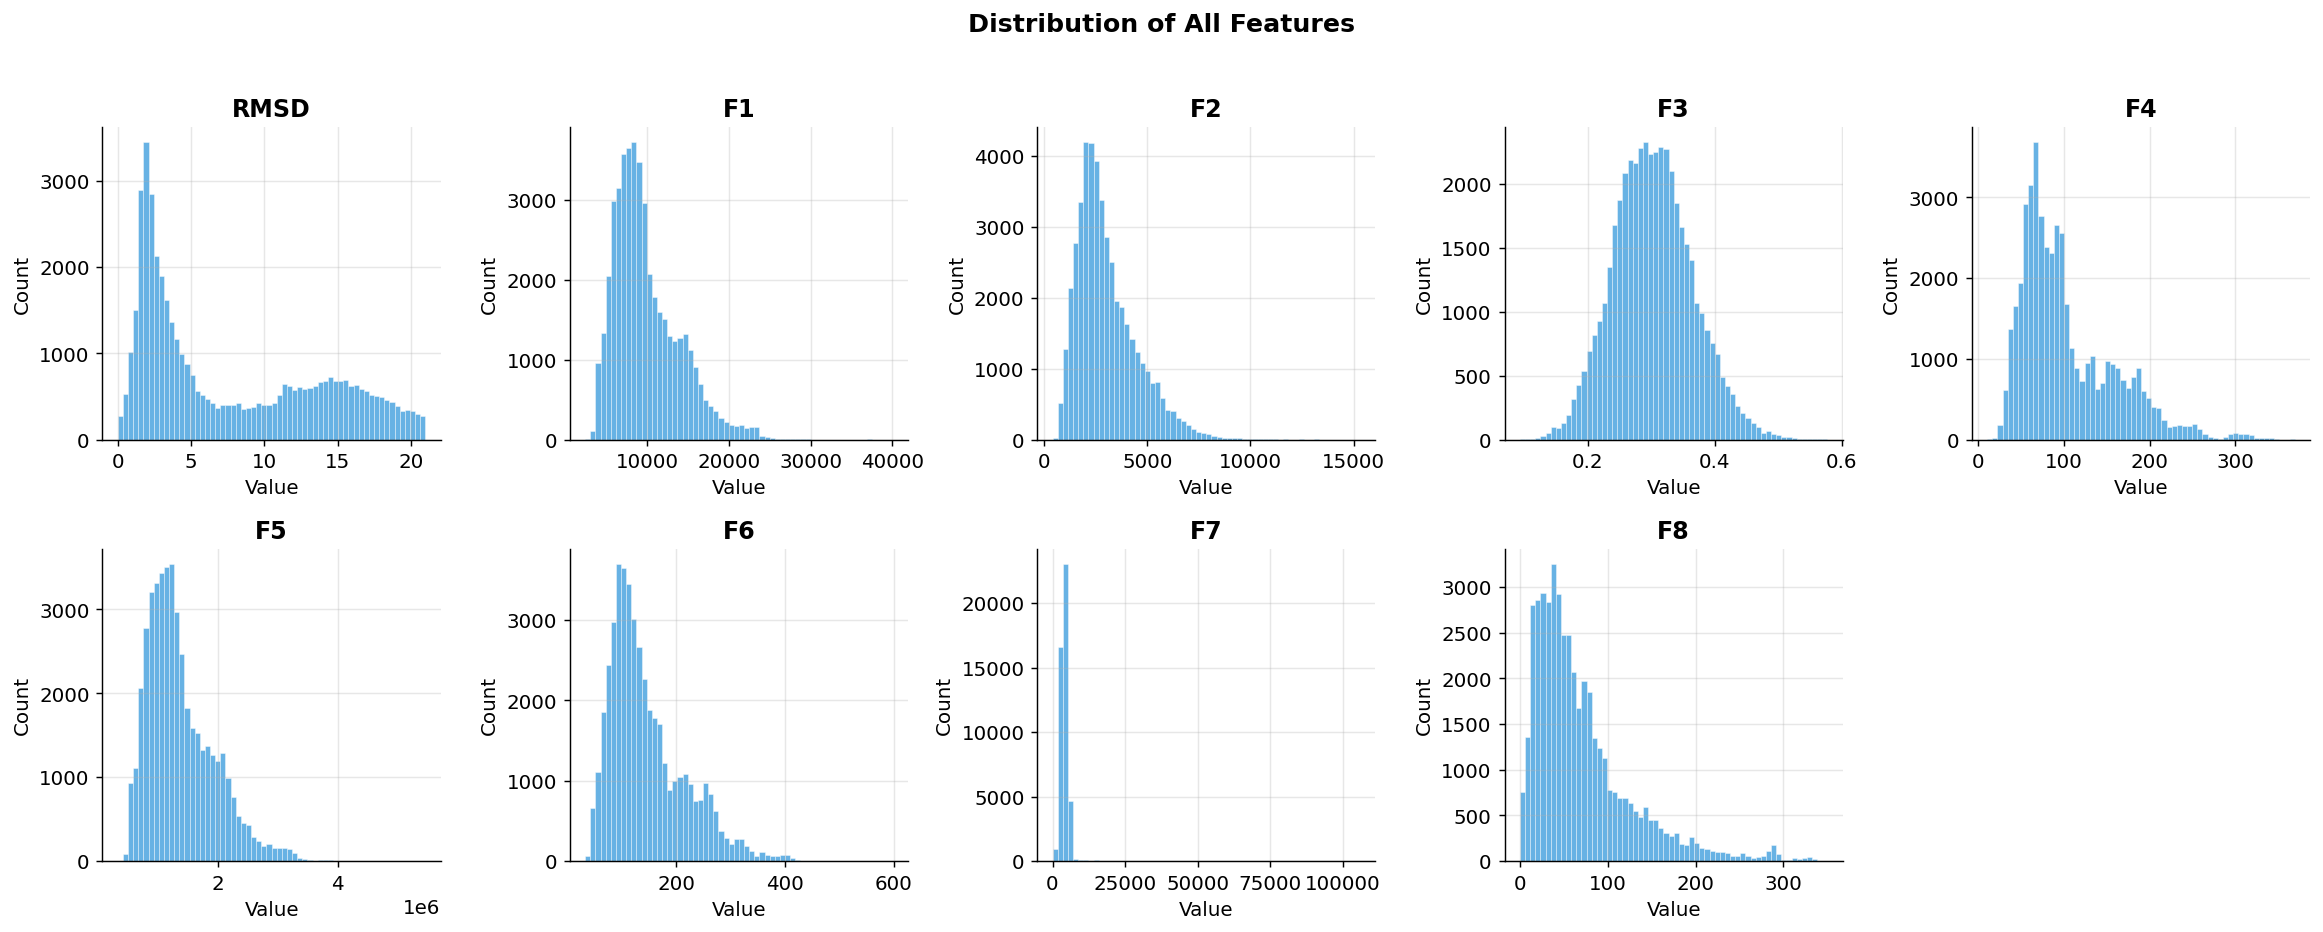

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
cols = df.columns.tolist()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=60, color='#3498db', alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide the unused 10th panel
axes[-1].set_visible(False)

fig.suptitle('Distribution of All Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

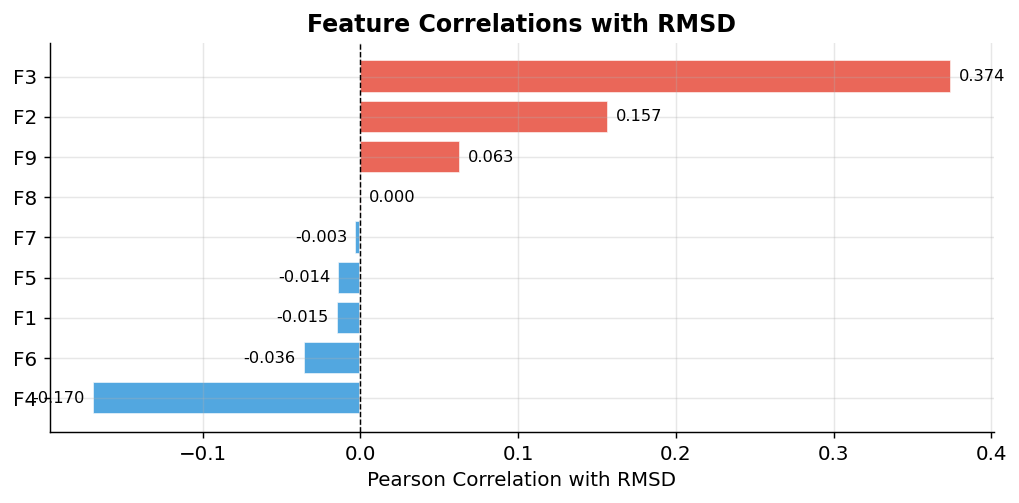


Top 2 positive correlators: F3 (non-polar ratio) and F2 (non-polar area)
Top negative correlator: F4 (Ramachandran outliers)


In [ ]:
features = ['F1','F2','F3','F4','F5','F6','F7','F8','F9']
corr_with_rmsd = df[features + ['RMSD']].corr()['RMSD'].drop('RMSD').sort_values()

colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_rmsd]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(corr_with_rmsd.index, corr_with_rmsd.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson Correlation with RMSD')
ax.set_title('Feature Correlations with RMSD', fontweight='bold')

for bar, val in zip(bars, corr_with_rmsd.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 2 positive correlators: F3 (non-polar ratio) and F2 (non-polar area)")
print("Top negative correlator: F4 (Ramachandran outliers)")

# ** 3. Quality Labels: Classifying Decoys by RMSD**

We divide decoys into three biologically meaningful tiers based on RMSD thresholds widely used in structural biology:

| Tier | RMSD Range | Interpretation |
|------|-----------|----------------|
| **Good** | 0–2 Å | Near-native; structure is essentially correct |
| **Medium** | 2–8 Å | Partially correct topology, wrong fine details |
| **Poor** | 8–21 Å | Largely incorrect; wrong fold |

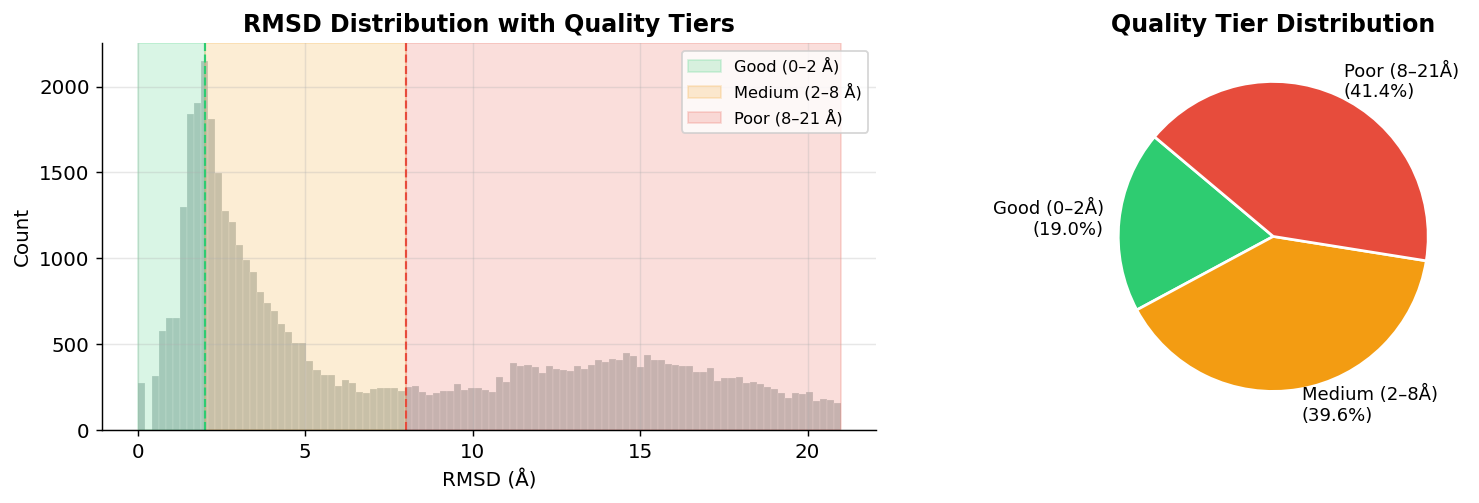


Decoy counts per tier:
  Good (0–2Å)         :  8,677  (19.0%)
  Medium (2–8Å)       : 18,119  (39.6%)
  Poor (8–21Å)        : 18,934  (41.4%)


In [ ]:
bins   = [0, 2, 8, 21]
labels = ['Good (0–2Å)', 'Medium (2–8Å)', 'Poor (8–21Å)']
df['quality'] = pd.cut(df['RMSD'], bins=bins, labels=labels, include_lowest=True)

counts = df['quality'].value_counts().reindex(labels)
pcts   = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# RMSD distribution with shaded tiers
ax = axes[0]
ax.hist(df['RMSD'], bins=100, color='#95a5a6', alpha=0.6, edgecolor='white', linewidth=0.2)
ax.axvspan(0,  2, alpha=0.18, color='#2ecc71', label='Good (0–2 Å)')
ax.axvspan(2,  8, alpha=0.18, color='#f39c12', label='Medium (2–8 Å)')
ax.axvspan(8, 21, alpha=0.18, color='#e74c3c', label='Poor (8–21 Å)')
ax.axvline(2, color='#2ecc71', linewidth=1.2, linestyle='--')
ax.axvline(8, color='#e74c3c', linewidth=1.2, linestyle='--')
ax.set_xlabel('RMSD (Å)')
ax.set_ylabel('Count')
ax.set_title('RMSD Distribution with Quality Tiers', fontweight='bold')
ax.legend(fontsize=9)

# Pie chart
ax2 = axes[1]
wedge_colors = ['#2ecc71', '#f39c12', '#e74c3c']
wedges, texts, autotexts = ax2.pie(
    counts, labels=[f"{l}\n({p:.1f}%)" for l, p in zip(labels, pcts)],
    colors=wedge_colors, autopct='%1.0f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_visible(False)
ax2.set_title('Quality Tier Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDecoy counts per tier:")
for label, cnt, pct in zip(labels, counts, pcts):
    print(f"  {label:20s}: {cnt:6,}  ({pct:.1f}%)")

---
## 4. Feature Differences Across Quality Tiers

For each feature, we compare distributions across the three quality tiers using:
- **Box plots** — median, IQR, and outliers
- **One-way ANOVA** — whether group means differ significantly

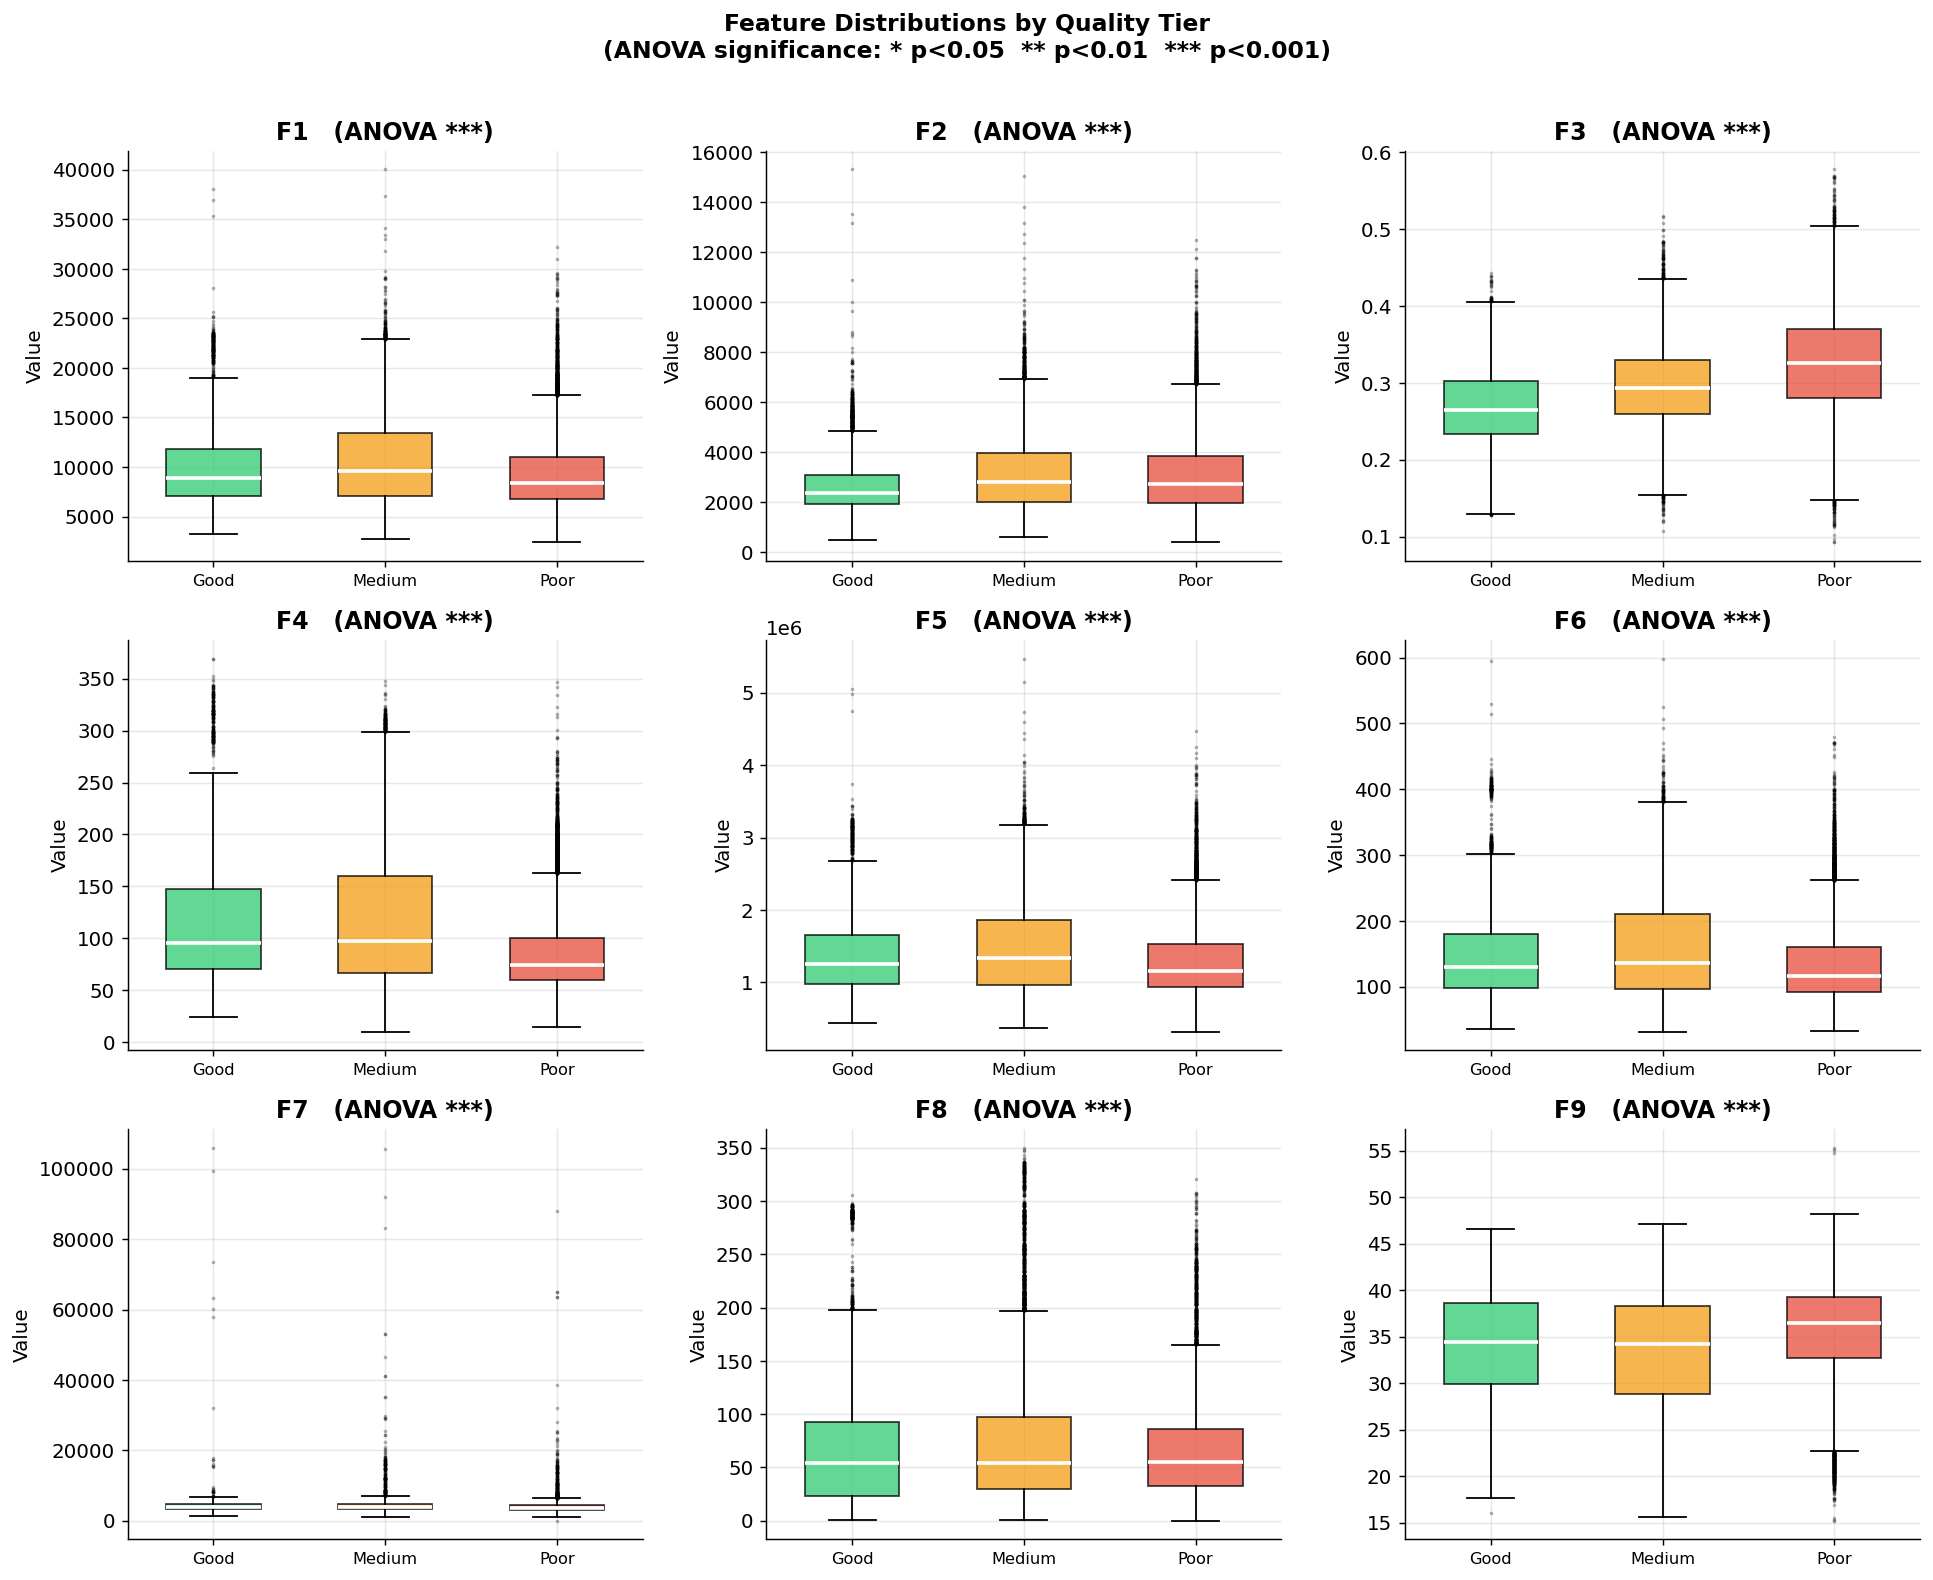

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
palette_list = ['#2ecc71', '#f39c12', '#e74c3c']

for i, feat in enumerate(features):
    ax = axes[i]
    groups = [df[df['quality'] == lbl][feat].values for lbl in labels]

    bp = ax.boxplot(
        groups,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker='o', markersize=1, alpha=0.3),
        widths=0.55
    )
    for patch, color in zip(bp['boxes'], palette_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # ANOVA p-value
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    ax.set_title(f'{feat}   (ANOVA {sig})', fontweight='bold')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Good', 'Medium', 'Poor'], fontsize=9)
    ax.set_ylabel('Value')

fig.suptitle('Feature Distributions by Quality Tier\n(ANOVA significance: * p<0.05  ** p<0.01  *** p<0.001)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

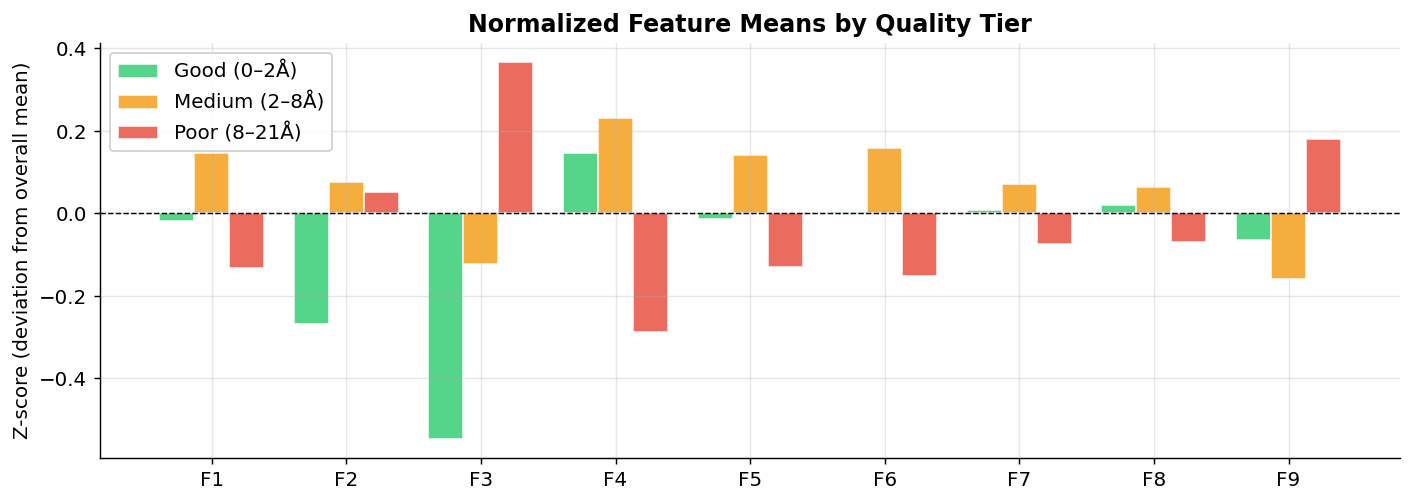

Key observations:
  F3 (non-polar ratio): increases monotonically Good → Medium → Poor
  F4 (Ramachandran outliers): highest in Medium, lowest in Poor (counter-intuitive)
  F9 (hydrophobic core): Poor tier has notably higher values


In [ ]:
# Normalized group means (z-scores relative to overall mean/std)
group_means = df.groupby('quality', observed=True)[features].mean()
overall_mean = df[features].mean()
overall_std  = df[features].std()
group_means_z = (group_means - overall_mean) / overall_std

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(features))
width = 0.26

for idx, (label, color) in enumerate(PALETTE.items()):
    vals = group_means_z.loc[label].values
    ax.bar(x + (idx - 1) * width, vals, width, label=label,
           color=color, alpha=0.82, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylabel('Z-score (deviation from overall mean)')
ax.set_title('Normalized Feature Means by Quality Tier', fontweight='bold')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  F3 (non-polar ratio): increases monotonically Good → Medium → Poor")
print("  F4 (Ramachandran outliers): highest in Medium, lowest in Poor (counter-intuitive)")
print("  F9 (hydrophobic core): Poor tier has notably higher values")

---
## 5. K-Means Clustering

We apply K-Means clustering to the **standardized** feature space (all 9 features) to discover natural groupings — without using RMSD labels — and then check how well those clusters align with quality tiers.

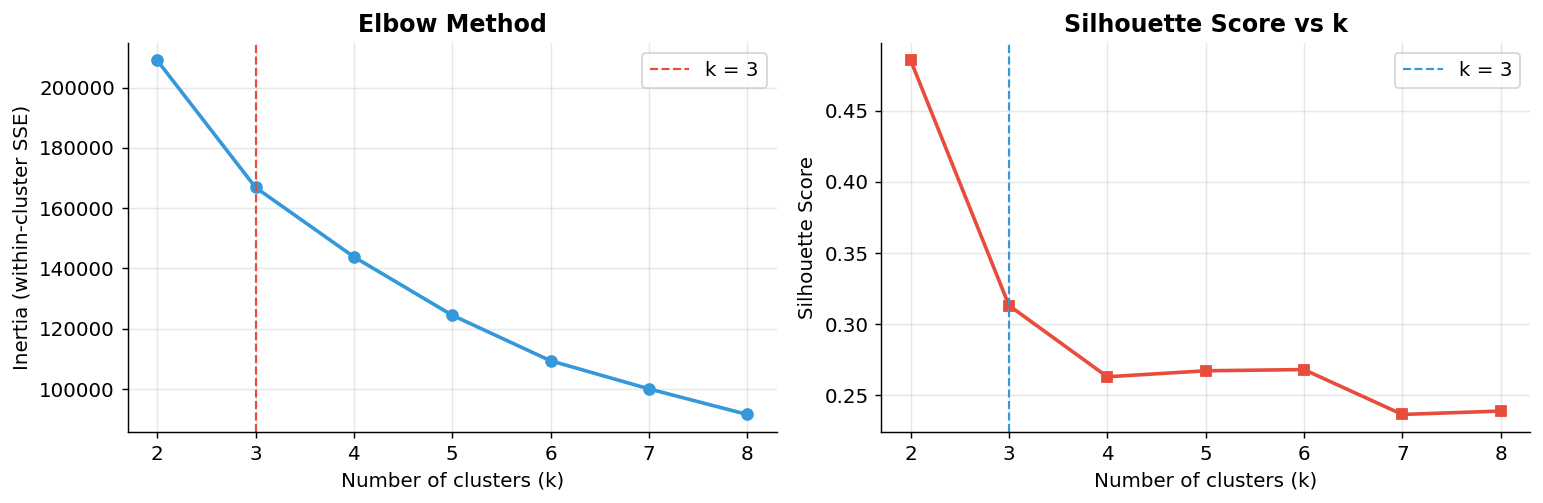

Silhouette scores: {2: np.float64(0.4852), 3: np.float64(0.3131), 4: np.float64(0.263), 5: np.float64(0.2672), 6: np.float64(0.2681), 7: np.float64(0.2366), 8: np.float64(0.2389)}


In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Elbow method
inertias   = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'o-', color='#3498db', linewidth=2, markersize=6)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].axvline(3, color='#e74c3c', linewidth=1.2, linestyle='--', label='k = 3')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 's-', color='#e74c3c', linewidth=2, markersize=6)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].axvline(3, color='#3498db', linewidth=1.2, linestyle='--', label='k = 3')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Silhouette scores: {dict(zip(K_range, [round(s, 4) for s in sil_scores]))}")

In [ ]:
# Fit final k=3 model
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km3.fit_predict(X_scaled)

# Rename clusters by ascending RMSD mean for interpretability
cluster_rmsd_mean = df.groupby('cluster')['RMSD'].mean().sort_values()
rename_map = {old: new for new, old in enumerate(cluster_rmsd_mean.index)}
df['cluster'] = df['cluster'].map(rename_map)
cluster_labels_map = {0: 'Cluster A (low RMSD)', 1: 'Cluster B (mid RMSD)', 2: 'Cluster C (high RMSD)'}
df['cluster_name'] = df['cluster'].map(cluster_labels_map)

print("=== K-Means Cluster Profiles ===")
profile = df.groupby('cluster_name').agg(
    Count=('RMSD', 'count'),
    RMSD_mean=('RMSD', 'mean'),
    RMSD_std=('RMSD', 'std')
).round(3)
print(profile)

print(f"\nOverall silhouette score (k=3): {silhouette_score(X_scaled, df['cluster'], sample_size=5000, random_state=42):.4f}")

=== K-Means Cluster Profiles ===
                       Count  RMSD_mean  RMSD_std
cluster_name                                     
Cluster A (low RMSD)    7825      7.197     6.439
Cluster B (mid RMSD)   22573      7.610     5.509
Cluster C (high RMSD)  15332      8.234     6.737

Overall silhouette score (k=3): 0.3131


---
## 6. PCA Visualization

We reduce the 9-dimensional feature space to 2 principal components for visualization.
PC1 captures **71%** of variance and is dominated by size-related features (F1, F2, F5, F6).  
PC2 captures **13%** and is dominated by **F3** (non-polar ratio) — the single strongest predictor of RMSD.

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f"Explained variance — PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Cumulative: {pca.explained_variance_ratio_.sum():.1%}")

# Loading heatmap
loadings = pd.DataFrame(pca.components_[:2].T, index=features,
                        columns=['PC1', 'PC2']).round(3)
print("\nPCA loadings:")
print(loadings)

Explained variance — PC1: 71.1%, PC2: 12.6%
Cumulative: 83.7%

PCA loadings:
      PC1    PC2
F1  0.388 -0.058
F2  0.364  0.321
F3  0.082  0.913
F4  0.372 -0.169
F5  0.387 -0.061
F6  0.386  0.006
F7  0.241 -0.045
F8  0.286 -0.091
F9 -0.365  0.132


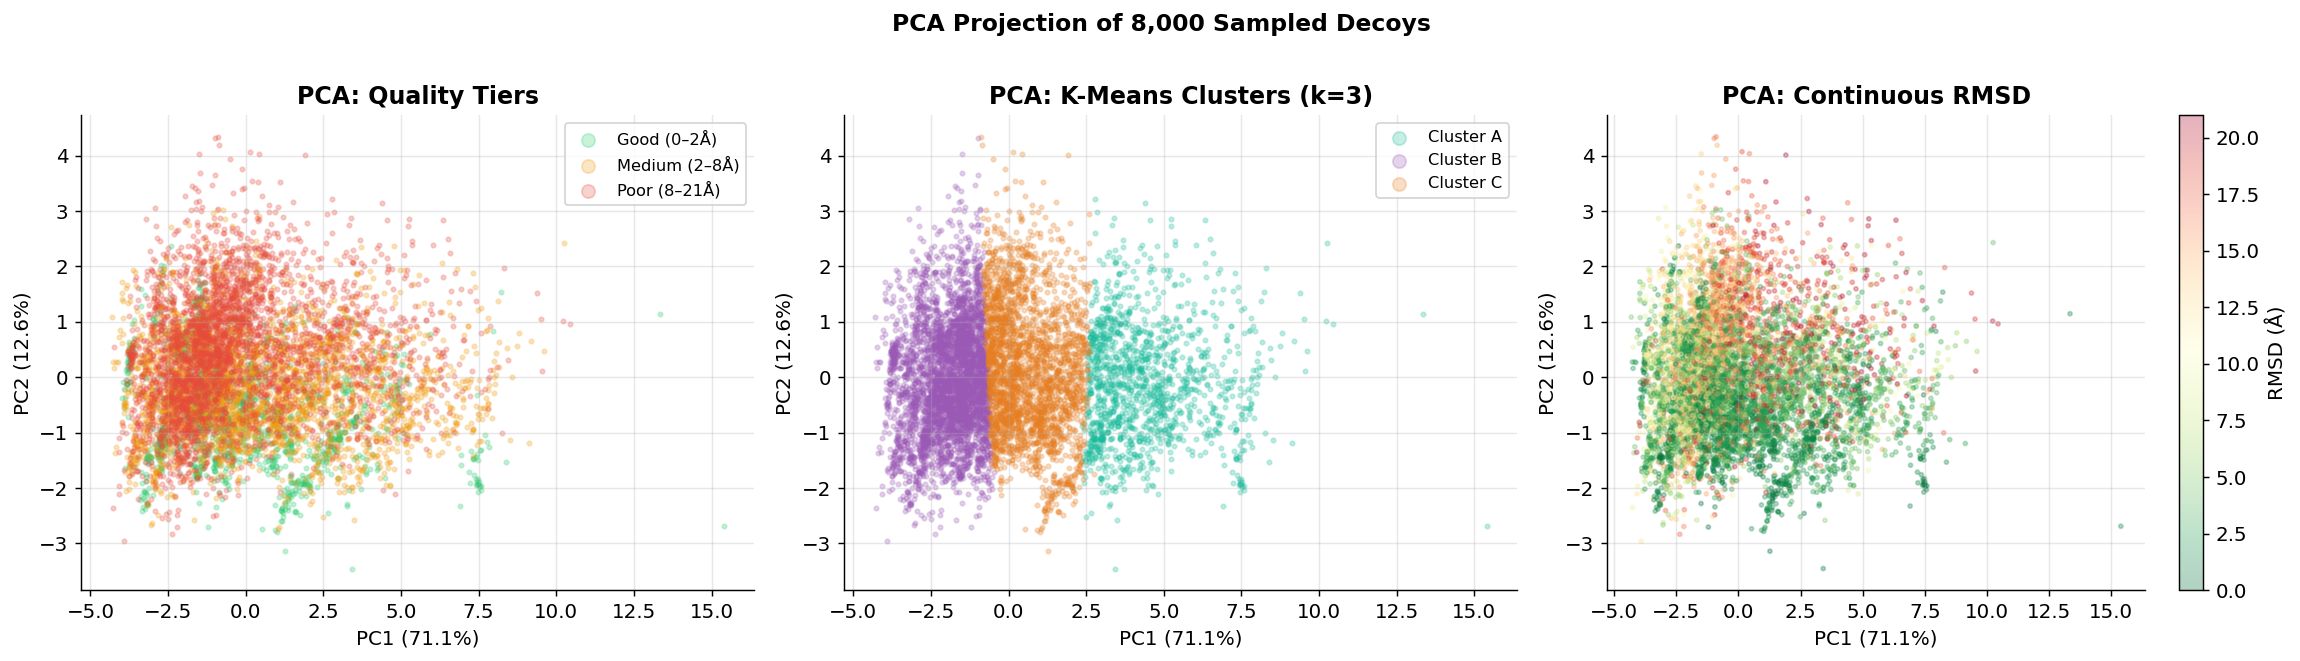

In [ ]:
# Subsample for scatter plot readability
sample = df.sample(8000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: coloured by quality tier
ax = axes[0]
for lbl, color in PALETTE.items():
    mask = sample['quality'] == lbl
    ax.scatter(sample.loc[mask, 'PC1'], sample.loc[mask, 'PC2'],
               c=color, alpha=0.25, s=6, label=lbl, rasterized=True)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: Quality Tiers', fontweight='bold')
ax.legend(markerscale=3, fontsize=9)

# Panel 2: coloured by K-Means cluster
ax = axes[1]
cluster_colors = {0: '#1abc9c', 1: '#9b59b6', 2: '#e67e22'}
for c, color in cluster_colors.items():
    mask = sample['cluster'] == c
    ax.scatter(sample.loc[mask, 'PC1'], sample.loc[mask, 'PC2'],
               c=color, alpha=0.25, s=6, label=f'Cluster {["A","B","C"][c]}', rasterized=True)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: K-Means Clusters (k=3)', fontweight='bold')
ax.legend(markerscale=3, fontsize=9)

# Panel 3: RMSD as continuous colour
ax = axes[2]
sc = ax.scatter(sample['PC1'], sample['PC2'],
                c=sample['RMSD'], cmap='RdYlGn_r',
                alpha=0.3, s=5, rasterized=True)
plt.colorbar(sc, ax=ax, label='RMSD (Å)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: Continuous RMSD', fontweight='bold')

fig.suptitle('PCA Projection of 8,000 Sampled Decoys', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

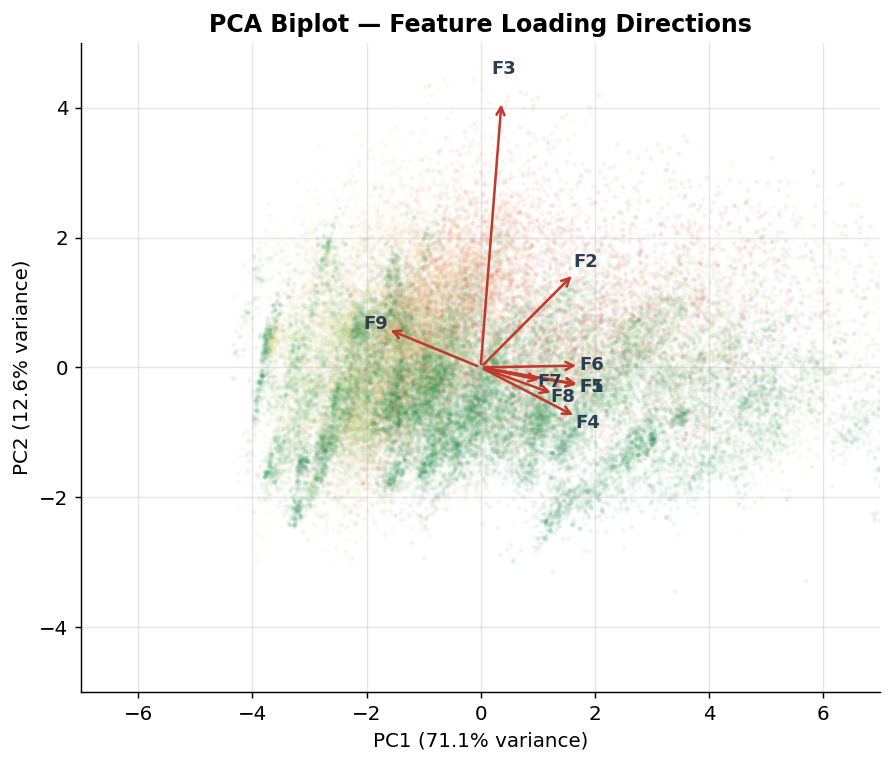

Interpretation:
  PC1 (horizontal) — size/scale axis: F1, F2, F5, F6 point right (larger proteins)
  PC2 (vertical)   — hydrophobicity axis: F3 points strongly upward
  F9 (hydrophobic core) points opposite to most size features — an independent signal


In [ ]:
# PCA loading biplot (arrows)
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df['RMSD'], cmap='RdYlGn_r',
           alpha=0.04, s=3, rasterized=True)

scale = 4.5
for j, feat in enumerate(features):
    lx, ly = pca.components_[0, j] * scale, pca.components_[1, j] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.4))
    ax.text(lx * 1.12, ly * 1.12, feat, fontsize=10,
            color='#2c3e50', fontweight='bold',
            ha='center', va='center')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA Biplot — Feature Loading Directions', fontweight='bold')
ax.set_xlim(-7, 7)
ax.set_ylim(-5, 5)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  PC1 (horizontal) — size/scale axis: F1, F2, F5, F6 point right (larger proteins)")
print("  PC2 (vertical)   — hydrophobicity axis: F3 points strongly upward")
print("  F9 (hydrophobic core) points opposite to most size features — an independent signal")

---
## 7. Deep Dive: The Two Most Discriminating Features

**F3** (non-polar surface ratio) and **F4** (Ramachandran outliers) show the clearest separation between quality tiers.

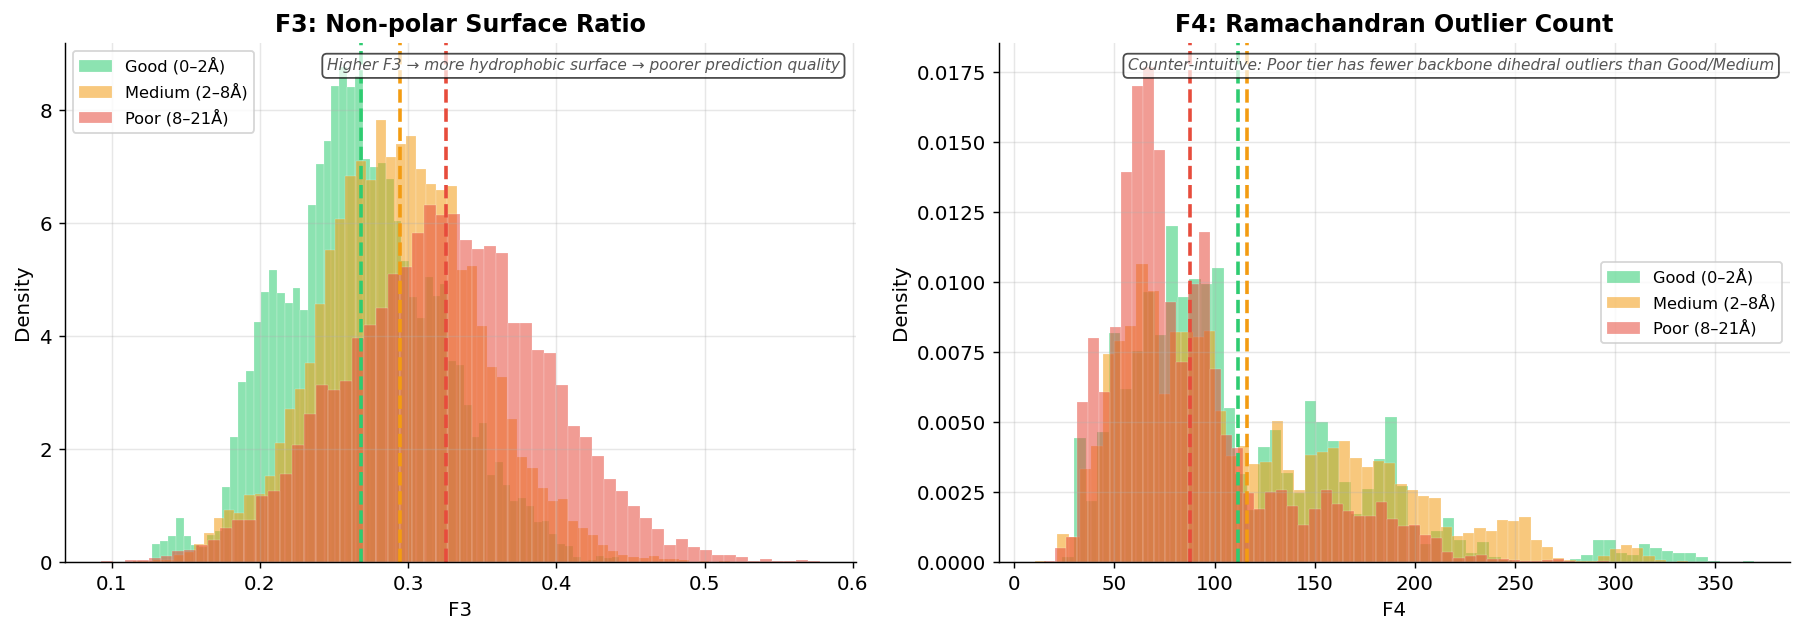

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, title, note in zip(
    axes,
    ['F3', 'F4'],
    ['F3: Non-polar Surface Ratio', 'F4: Ramachandran Outlier Count'],
    ['Higher F3 → more hydrophobic surface → poorer prediction quality',
     'Counter-intuitive: Poor tier has fewer backbone dihedral outliers than Good/Medium']
):
    for lbl, color in PALETTE.items():
        vals = df[df['quality'] == lbl][feat]
        ax.hist(vals, bins=60, alpha=0.55, color=color, label=lbl,
                density=True, edgecolor='white', linewidth=0.2)
        ax.axvline(vals.mean(), color=color, linewidth=2, linestyle='--')

    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.text(0.98, 0.97, note, transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5, style='italic',
            color='#555', wrap=True,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.show()

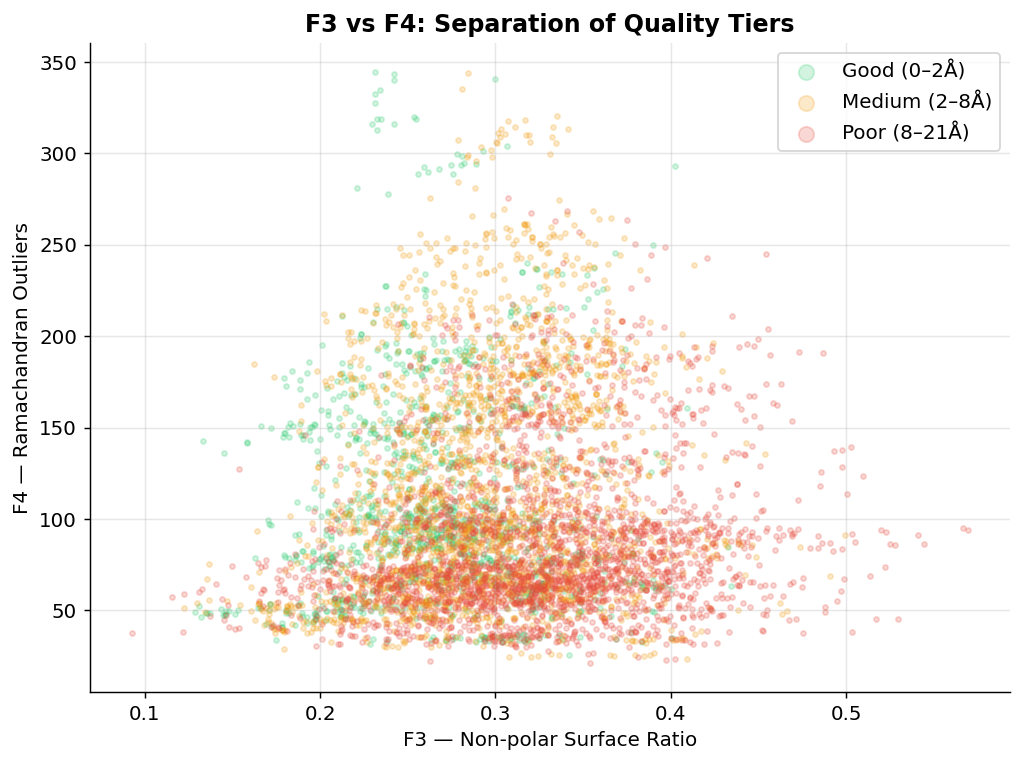

In [ ]:
# 2D scatter: F3 vs F4, coloured by quality
sample2 = df.sample(6000, random_state=1)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, color in PALETTE.items():
    mask = sample2['quality'] == lbl
    ax.scatter(sample2.loc[mask, 'F3'], sample2.loc[mask, 'F4'],
               c=color, alpha=0.22, s=8, label=lbl, rasterized=True)

ax.set_xlabel('F3 — Non-polar Surface Ratio')
ax.set_ylabel('F4 — Ramachandran Outliers')
ax.set_title('F3 vs F4: Separation of Quality Tiers', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

---
## 8. Correlation Heatmap

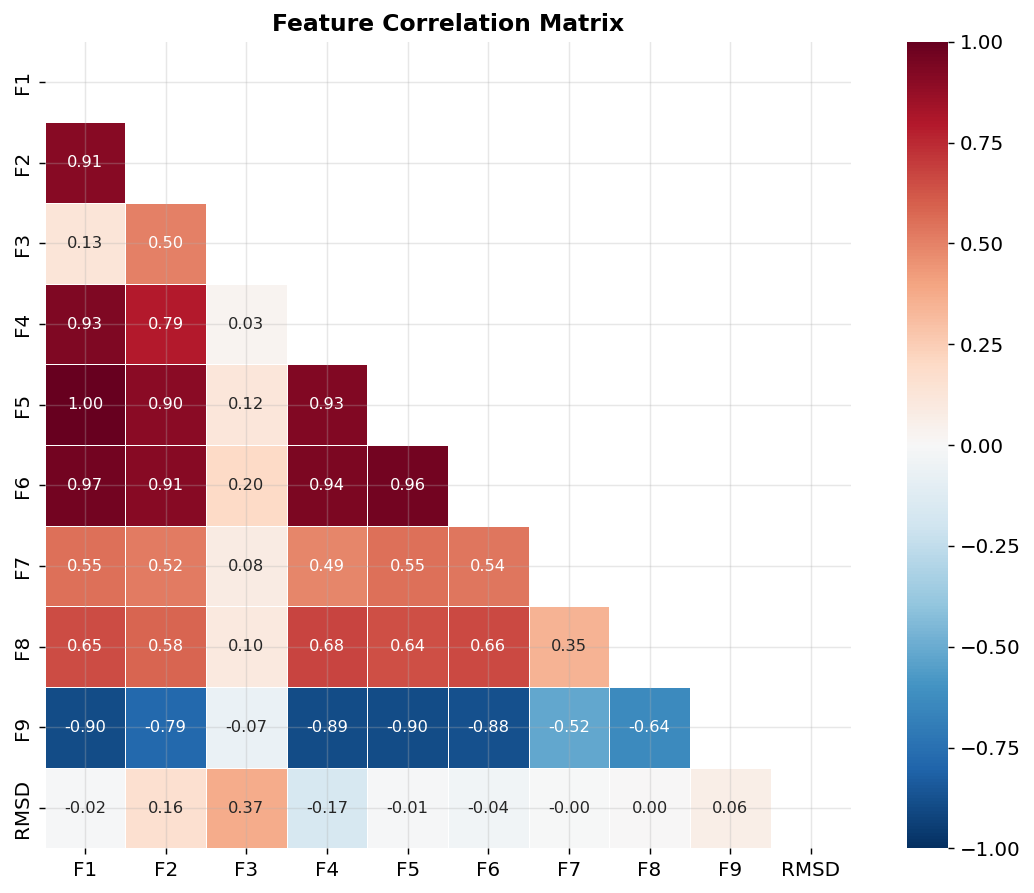

In [ ]:
corr = df[features + ['RMSD']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Summary & Key Findings

| Finding | Detail |
|---------|--------|
| **F3 is the strongest RMSD predictor** | Pearson r = +0.374. Higher non-polar surface ratio → larger structural error. |
| **F4 shows a counter-intuitive pattern** | Poor-quality decoys have *fewer* Ramachandran outliers than Good/Medium ones, suggesting force-field biases in CASP decoy generation. |
| **K-Means clusters correlate weakly with RMSD** | Silhouette ≈ 0.32; clusters are primarily driven by protein size (PC1, 71% variance), not prediction quality. |
| **PC2 captures quality** | The second PCA axis is dominated by F3 — the hydrophobicity axis aligns better with RMSD than the size axis. |
| **Size features dominate the feature space** | F1, F2, F5, F6 are highly correlated with each other (large proteins → large values on all four). |


In [ ]:
print("=" * 55)
print("ANALYSIS COMPLETE")
print("=" * 55)
print(f"Total decoys analysed : {len(df):,}")
print(f"Good  (0–2 Å)         : {(df['quality']=='Good (0–2Å)').sum():,}  ({(df['quality']=='Good (0–2Å)').mean():.1%})")
print(f"Medium (2–8 Å)        : {(df['quality']=='Medium (2–8Å)').sum():,}  ({(df['quality']=='Medium (2–8Å)').mean():.1%})")
print(f"Poor  (8–21 Å)        : {(df['quality']=='Poor (8–21Å)').sum():,}  ({(df['quality']=='Poor (8–21Å)').mean():.1%})")
print(f"K-Means silhouette    : {silhouette_score(X_scaled, df['cluster'], sample_size=5000, random_state=42):.4f}")
print(f"PCA PC1+PC2 variance  : {pca.explained_variance_ratio_.sum():.1%}")
print(f"Strongest RMSD corr.  : F3 = +0.374")

ANALYSIS COMPLETE
Total decoys analysed : 45,730
Good  (0–2 Å)         : 8,677  (19.0%)
Medium (2–8 Å)        : 18,119  (39.6%)
Poor  (8–21 Å)        : 18,934  (41.4%)
K-Means silhouette    : 0.3131
PCA PC1+PC2 variance  : 83.7%
Strongest RMSD corr.  : F3 = +0.374


Thank you!